<a href="https://colab.research.google.com/github/siva349/Momentum_Strategy_research/blob/main/backTest1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  NSE Sharpe Momentum Backtest
  Period: 2020-01-01 → 2026-03-01
  Capital: ₹1,000,000  |  Top 25 stocks  |  Monthly rebalance
[Universe] Loaded 2253 symbols from EQUITY_L.csv

[Data] Downloading/loading price data for 2253 symbols...
       Cached files go to ./price_cache/
       First run can take 30-60 minutes. Subsequent runs are instant.



Fetching prices:   0%|          | 7/2253 [00:04<20:40,  1.81it/s]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 5PAISA-RE.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['5PAISA-RE.NS']: YFTzMissingError('possibly delisted; no timezone found')
Fetching prices:   3%|▎         | 60/2253 [00:33<17:04,  2.14it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AEPL.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-01-01 -> 2026-03-01) (Yahoo error = "Data doesn\'t exist for startDate = 1546281000, endDate = 1772303400")')
Fetching prices:  12%|█▏        | 277/2253 [02:28<18:04,  1.82it/s]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BCPL.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BCPL.NS']: YFTzMissingError('possibly delisted; no timezone found')
Fetching prices:  


[Data] Could not fetch 54 symbols (delisted / no data): ['5PAISA-RE', 'AARNAV', 'ADVAIT', 'AEPL', 'AEQUS', 'ALGOQUANT', 'AMAGI', 'ARIS', 'AYE', 'BCPL']...

[Data] Price matrix shape: (1771, 2199)  (2199 stocks × 1771 days)

[Backtest] 74 rebalance dates from 2020-01-01 to 2026-02-02


Rebalancing: 100%|██████████| 74/74 [01:08<00:00,  1.08it/s]



[Benchmark] Downloading ^CRSLDX...

════════════════════════════════════════════════════
  Metric                    Strategy   Benchmark
────────────────────────────────────────────────────
  Total Return                742.2%      130.9%
  CAGR                         41.9%       14.7%
  Ann. Volatility              31.9%       18.8%
  Sharpe Ratio                  1.11        0.44
  Sortino Ratio                 1.46        0.45
  Max Drawdown                -32.5%      -31.6%
  Calmar Ratio                  1.29        0.47
  Win Rate (Mo)                67.1%       69.9%
════════════════════════════════════════════════════

  Total trades     : 2347
  Est. total costs : ₹513,724
  Avg trades/month : 31.7

[Output] CSVs saved → backtest_results.csv, trade_log.csv, holdings_log.csv

[Output] Chart saved → backtest_report.png


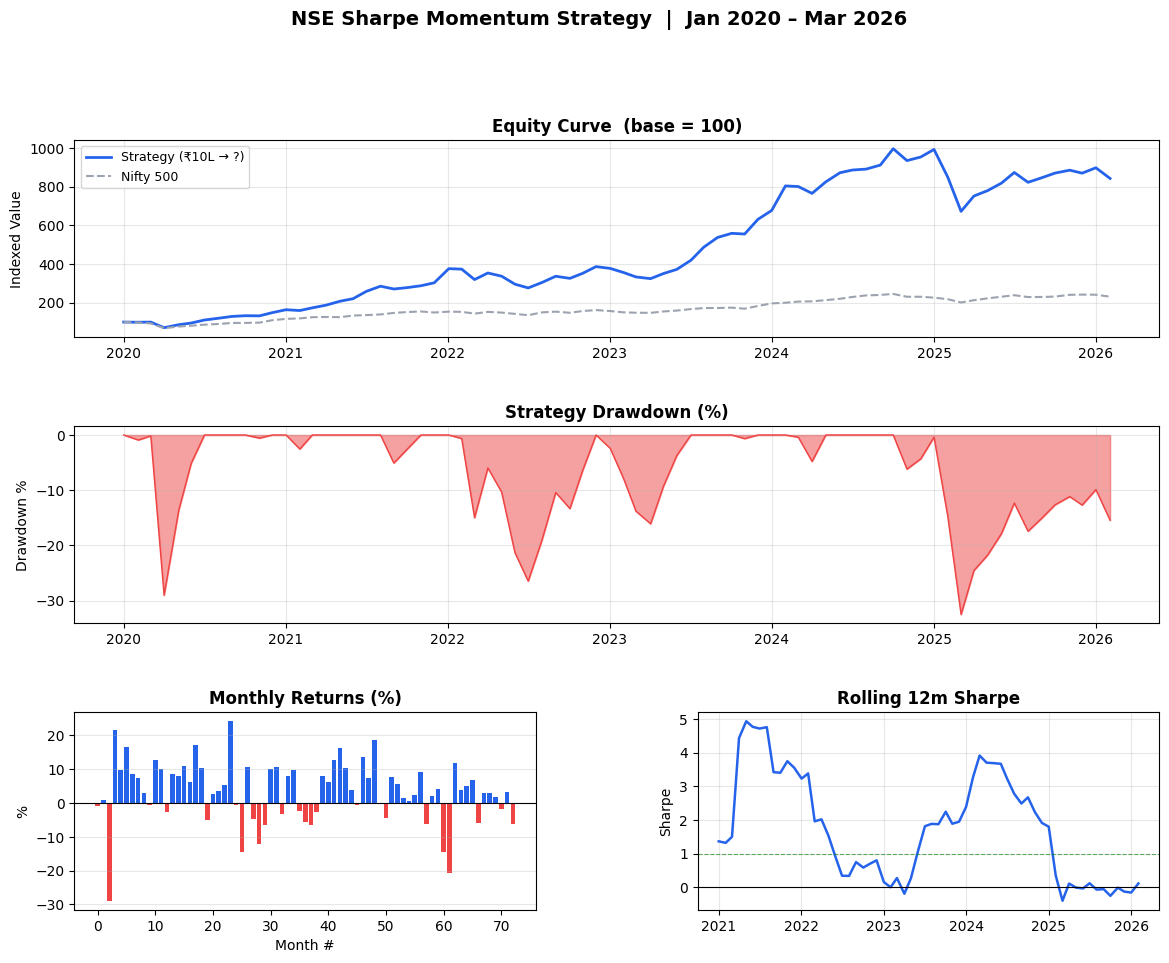


  Starting capital : ₹   1,000,000
  Final portfolio  : ₹   8,409,882
  Absolute gain    : ₹   7,409,882



In [1]:
"""
NSE Sharpe Momentum Strategy Backtest
======================================
Universe  : All NSE-listed stocks (via yfinance .NS suffix)
Signal    : Average Sharpe ratio across 6, 9, 12-month lookback windows
Filters   : Minimum median daily volume + circuit-breaker proxy (max single-day % move)
Portfolio : Top 25 stocks, equal weight, ₹10,00,000 capital
Rebalance : Monthly (first trading day of each month)
Period    : 1 Jan 2020 → 1 Mar 2026
Benchmark : Nifty 500 (^CRSLDX) via yfinance

HOW TO RUN
----------
1. Install dependencies:
   pip install yfinance pandas numpy matplotlib seaborn tqdm

2. Download EQUITY_L.csv from NSE:
   https://www.nseindia.com/market-data/securities-available-for-trading
   Save it in the same folder as this script.

3. Run:
   python nse_sharpe_backtest.py

   First run will download price data (~30-60 min for full universe).
   Data is cached to ./price_cache/ so subsequent runs are fast.

OUTPUTS
-------
- backtest_results.csv       : Monthly portfolio NAV + benchmark
- trade_log.csv              : Every buy/sell with date, symbol, shares, price
- holdings_log.csv           : Month-end holdings snapshot
- backtest_report.png        : Equity curve + drawdown chart
- Console                    : Summary statistics table
"""

import os
import time
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIGURATION  ← edit these as needed
# ─────────────────────────────────────────────
START_DATE          = "2019-01-01"   # download from here (needs warm-up before 2020)
BACKTEST_START      = "2020-01-01"   # strategy goes live from here
BACKTEST_END        = "2026-03-01"
CAPITAL             = 1_000_000      # ₹10,00,000
TOP_N               = 25             # number of stocks to hold
LOOKBACK_MONTHS     = [6, 9, 12]     # Sharpe lookback windows (months)
TRADING_DAYS_MONTH  = 21             # approx trading days per month
RF_ANNUAL           = 0.065          # risk-free rate (approx 91-day T-bill avg)

# Filters
MIN_MEDIAN_VOLUME   = 500_000        # minimum median daily volume (shares)
MAX_CIRCUIT_DAYS    = 4              # max days with |return| >= circuit threshold in lookback
CIRCUIT_THRESHOLD   = 0.195          # 19.5% move in a day → likely circuit hit proxy

# Data
EQUITY_CSV          = "EQUITY_L.csv" # downloaded from NSE website
CACHE_DIR           = "./price_cache"
BENCHMARK_TICKER    = "^CRSLDX"      # Nifty 500 Total Return Index on Yahoo Finance

# Transaction costs
BROKERAGE_PCT       = 0.0003         # 0.03% per leg (discount broker)
STT_PCT             = 0.001          # 0.1% on sell side
OTHER_COSTS_PCT     = 0.0002         # exchange + SEBI charges
SLIPPAGE_PCT        = 0.001          # 0.1% market impact estimate

TOTAL_BUY_COST      = BROKERAGE_PCT + OTHER_COSTS_PCT + SLIPPAGE_PCT
TOTAL_SELL_COST     = BROKERAGE_PCT + STT_PCT + OTHER_COSTS_PCT + SLIPPAGE_PCT

# ─────────────────────────────────────────────
# STEP 1: LOAD UNIVERSE
# ─────────────────────────────────────────────

def load_universe(equity_csv: str) -> list[str]:
    """
    Load stock symbols from NSE's EQUITY_L.csv.
    Falls back to a hardcoded Nifty 500-ish list if file not found.
    """
    if os.path.exists(equity_csv):
        df = pd.read_csv(equity_csv)
        # NSE CSV has a column called 'SYMBOL'
        symbols = df["SYMBOL"].dropna().str.strip().tolist()
        # Filter to EQ series only if column present
        if "SERIES" in df.columns:
            symbols = df[df["SERIES"] == "EQ"]["SYMBOL"].dropna().str.strip().tolist()
        print(f"[Universe] Loaded {len(symbols)} symbols from {equity_csv}")
        return symbols
    else:
        # Fallback: representative large/mid-cap list (Nifty 500 proximate)
        print(f"[Universe] {equity_csv} not found. Using built-in fallback list (~200 stocks).")
        print("           Download EQUITY_L.csv from NSE for full universe coverage.\n")
        return FALLBACK_SYMBOLS


# ─────────────────────────────────────────────
# STEP 2: DOWNLOAD & CACHE PRICE DATA
# ─────────────────────────────────────────────

def download_prices(symbols: list[str], start: str, end: str) -> pd.DataFrame:
    """
    Download adjusted close prices + volume for all symbols.
    Uses a local cache (one CSV per symbol) to avoid re-downloading.
    Returns a dict: {"close": DataFrame, "volume": DataFrame}
    """
    os.makedirs(CACHE_DIR, exist_ok=True)
    all_close  = {}
    all_volume = {}

    print(f"\n[Data] Downloading/loading price data for {len(symbols)} symbols...")
    print(f"       Cached files go to {CACHE_DIR}/")
    print(f"       First run can take 30-60 minutes. Subsequent runs are instant.\n")

    failed = []
    for sym in tqdm(symbols, desc="Fetching prices"):
        cache_file = os.path.join(CACHE_DIR, f"{sym}.csv")
        ticker     = f"{sym}.NS"

        # Load from cache if exists and is recent enough
        if os.path.exists(cache_file):
            try:
                df = pd.read_csv(cache_file, index_col=0, parse_dates=True)
                # Re-download only if cache is older than 2 days
                cache_age = (datetime.now() - datetime.fromtimestamp(
                    os.path.getmtime(cache_file))).days
                if cache_age <= 2 and pd.Timestamp(end) <= df.index[-1] + pd.Timedelta(days=5):
                    all_close[sym]  = df["Close"]
                    all_volume[sym] = df["Volume"]
                    continue
            except Exception:
                pass  # re-download on any read error

        # Download fresh
        try:
            df = yf.download(
                ticker,
                start=start,
                end=end,
                auto_adjust=True,
                progress=False,
                threads=False
            )
            if df.empty or len(df) < 60:
                failed.append(sym)
                continue

            # yfinance >= 0.2 returns MultiIndex columns when downloading single ticker
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            df = df[["Close", "Volume"]].dropna(how="all")
            df.to_csv(cache_file)
            all_close[sym]  = df["Close"]
            all_volume[sym] = df["Volume"]
            time.sleep(0.05)  # gentle rate limiting
        except Exception as e:
            failed.append(sym)

    if failed:
        print(f"\n[Data] Could not fetch {len(failed)} symbols (delisted / no data): "
              f"{failed[:10]}{'...' if len(failed) > 10 else ''}")

    close_df  = pd.DataFrame(all_close).sort_index()
    volume_df = pd.DataFrame(all_volume).sort_index()

    # Align indices
    close_df  = close_df.loc[start:end]
    volume_df = volume_df.loc[start:end]

    print(f"\n[Data] Price matrix shape: {close_df.shape}  "
          f"({close_df.shape[1]} stocks × {close_df.shape[0]} days)")
    return {"close": close_df, "volume": volume_df}


# ─────────────────────────────────────────────
# STEP 3: FACTOR COMPUTATION
# ─────────────────────────────────────────────

RF_DAILY = (1 + RF_ANNUAL) ** (1 / 252) - 1

def compute_sharpe(returns: pd.Series, n_days: int) -> float:
    """Rolling Sharpe over last n_days of daily returns."""
    r = returns.iloc[-n_days:]
    excess = r - RF_DAILY
    if excess.std() == 0 or len(excess) < n_days * 0.7:
        return np.nan
    return (excess.mean() / excess.std()) * np.sqrt(252)


def compute_scores(close: pd.DataFrame, volume: pd.DataFrame,
                   as_of_date: pd.Timestamp) -> pd.Series:
    """
    For each stock, compute average Sharpe across lookback windows
    and apply liquidity + circuit filters.

    Returns a Series of scores (NaN = filtered out).
    """
    lookback_days = {m: m * TRADING_DAYS_MONTH for m in LOOKBACK_MONTHS}
    max_lookback  = max(lookback_days.values())

    # Slice history up to (but not including) as_of_date
    close_hist  = close.loc[:as_of_date].iloc[-(max_lookback + 5):]
    volume_hist = volume.loc[:as_of_date].iloc[-(max_lookback + 5):]

    returns = close_hist.pct_change().dropna(how="all")

    scores = {}
    for sym in close_hist.columns:
        ret    = returns[sym].dropna()
        vol    = volume_hist[sym].dropna()

        if len(ret) < lookback_days[min(LOOKBACK_MONTHS)] * 0.7:
            continue  # insufficient history

        # ── Liquidity filter ─────────────────────────────────────
        median_vol = vol.iloc[-lookback_days[6]:].median()
        if pd.isna(median_vol) or median_vol < MIN_MEDIAN_VOLUME:
            continue

        # ── Circuit-breaker proxy filter ─────────────────────────
        # Count days where absolute daily return >= 19.5% (circuit proxy)
        circuit_days = (ret.abs() >= CIRCUIT_THRESHOLD).sum()
        if circuit_days > MAX_CIRCUIT_DAYS:
            continue

        # ── Sharpe across lookback windows ───────────────────────
        sharpe_vals = []
        for months, days in lookback_days.items():
            s = compute_sharpe(ret, days)
            if not np.isnan(s):
                sharpe_vals.append(s)

        if len(sharpe_vals) < len(LOOKBACK_MONTHS):
            continue  # need all three windows

        scores[sym] = np.mean(sharpe_vals)

    return pd.Series(scores)


# ─────────────────────────────────────────────
# STEP 4: PORTFOLIO CONSTRUCTION
# ─────────────────────────────────────────────

def get_rebalance_dates(close: pd.DataFrame,
                        start: str, end: str) -> list[pd.Timestamp]:
    """Return first trading day of each month within [start, end]."""
    trading_days = close.loc[start:end].index
    monthly      = (pd.Series(trading_days)
                    .groupby(pd.to_datetime(trading_days).to_period("M"))
                    .first()
                    .tolist())
    return monthly


def run_backtest(data: dict) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Core backtest engine.

    Returns:
        nav_df      : monthly NAV series
        trade_log   : every transaction
        holdings_log: month-end holdings
    """
    close  = data["close"]
    volume = data["volume"]

    rebal_dates = get_rebalance_dates(close, BACKTEST_START, BACKTEST_END)
    print(f"\n[Backtest] {len(rebal_dates)} rebalance dates from "
          f"{rebal_dates[0].date()} to {rebal_dates[-1].date()}")

    # State
    cash      = float(CAPITAL)
    holdings  = {}          # {symbol: shares}
    nav_rows  = []
    trade_rows  = []
    holding_rows = []

    for i, rebal_date in enumerate(tqdm(rebal_dates, desc="Rebalancing")):

        # ── Mark-to-market current portfolio at rebalance price ──
        portfolio_value = cash
        for sym, shares in holdings.items():
            if sym in close.columns and rebal_date in close.index:
                price = close.loc[rebal_date, sym]
                if not np.isnan(price):
                    portfolio_value += shares * price

        # ── Score stocks ────────────────────────────────────────
        scores = compute_scores(close, volume, rebal_date)
        if scores.empty:
            nav_rows.append({"date": rebal_date, "portfolio_nav": portfolio_value})
            continue

        # Select top N by score
        new_targets = scores.nlargest(TOP_N).index.tolist()

        # ── Execute rebalance ────────────────────────────────────
        target_weight  = 1.0 / TOP_N
        target_value   = portfolio_value * target_weight

        # Sell positions not in new targets
        for sym in list(holdings.keys()):
            if sym not in new_targets:
                if sym in close.columns and rebal_date in close.index:
                    price = close.loc[rebal_date, sym]
                    if not np.isnan(price) and holdings[sym] > 0:
                        proceeds = holdings[sym] * price * (1 - TOTAL_SELL_COST)
                        cash += proceeds
                        trade_rows.append({
                            "date": rebal_date, "symbol": sym,
                            "action": "SELL", "shares": holdings[sym],
                            "price": round(price, 2),
                            "value": round(proceeds, 2),
                            "cost_pct": round(TOTAL_SELL_COST * 100, 3)
                        })
                        del holdings[sym]

        # Rebalance existing positions and buy new ones
        for sym in new_targets:
            if sym not in close.columns:
                continue
            if rebal_date not in close.index:
                continue
            price = close.loc[rebal_date, sym]
            if np.isnan(price) or price <= 0:
                continue

            current_shares = holdings.get(sym, 0)
            current_value  = current_shares * price
            diff_value     = target_value - current_value

            if abs(diff_value) < price:  # less than 1 share difference, skip
                continue

            if diff_value > 0:
                # Buy
                cost = diff_value * (1 + TOTAL_BUY_COST)
                if cash >= cost:
                    shares_to_buy = int(diff_value / price)
                    if shares_to_buy <= 0:
                        continue
                    actual_cost = shares_to_buy * price * (1 + TOTAL_BUY_COST)
                    cash -= actual_cost
                    holdings[sym] = current_shares + shares_to_buy
                    trade_rows.append({
                        "date": rebal_date, "symbol": sym,
                        "action": "BUY", "shares": shares_to_buy,
                        "price": round(price, 2),
                        "value": round(actual_cost, 2),
                        "cost_pct": round(TOTAL_BUY_COST * 100, 3)
                    })
            else:
                # Trim / partial sell
                shares_to_sell = int(abs(diff_value) / price)
                if shares_to_sell <= 0 or shares_to_sell > current_shares:
                    continue
                proceeds = shares_to_sell * price * (1 - TOTAL_SELL_COST)
                cash += proceeds
                holdings[sym] = current_shares - shares_to_sell
                trade_rows.append({
                    "date": rebal_date, "symbol": sym,
                    "action": "TRIM", "shares": shares_to_sell,
                    "price": round(price, 2),
                    "value": round(proceeds, 2),
                    "cost_pct": round(TOTAL_SELL_COST * 100, 3)
                })

        # ── Record NAV ────────────────────────────────────────────
        portfolio_value = cash
        for sym, shares in holdings.items():
            if sym in close.columns and rebal_date in close.index:
                price = close.loc[rebal_date, sym]
                if not np.isnan(price):
                    portfolio_value += shares * price

        nav_rows.append({"date": rebal_date, "portfolio_nav": portfolio_value})

        # ── Record holdings snapshot ──────────────────────────────
        for sym, shares in holdings.items():
            if sym in close.columns and rebal_date in close.index:
                price = close.loc[rebal_date, sym]
                if not np.isnan(price):
                    holding_rows.append({
                        "date": rebal_date, "symbol": sym,
                        "shares": shares,
                        "price": round(price, 2),
                        "value": round(shares * price, 2),
                        "score": scores.get(sym, np.nan)
                    })

    nav_df       = pd.DataFrame(nav_rows).set_index("date")
    trade_log    = pd.DataFrame(trade_rows)
    holdings_log = pd.DataFrame(holding_rows)

    return nav_df, trade_log, holdings_log


# ─────────────────────────────────────────────
# STEP 5: BENCHMARK
# ─────────────────────────────────────────────

def load_benchmark(start: str, end: str) -> pd.Series:
    """Download Nifty 500 TRI as benchmark."""
    print(f"\n[Benchmark] Downloading {BENCHMARK_TICKER}...")
    try:
        df = yf.download(BENCHMARK_TICKER, start=start, end=end,
                         auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df["Close"].dropna()
    except Exception as e:
        print(f"[Benchmark] Warning: could not download benchmark ({e}). "
              f"Trying ^NSEI (Nifty 50) as fallback.")
        try:
            df = yf.download("^NSEI", start=start, end=end,
                             auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            return df["Close"].dropna()
        except Exception:
            return pd.Series(dtype=float)


# ─────────────────────────────────────────────
# STEP 6: PERFORMANCE METRICS
# ─────────────────────────────────────────────

def compute_metrics(nav: pd.Series, label: str = "Strategy") -> dict:
    """Compute standard performance metrics from a NAV series."""
    returns = nav.pct_change().dropna()
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25

    total_return  = (nav.iloc[-1] / nav.iloc[0]) - 1
    cagr          = (1 + total_return) ** (1 / n_years) - 1
    ann_vol       = returns.std() * np.sqrt(12)   # monthly returns
    sharpe        = (cagr - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan

    # Drawdown
    rolling_max   = nav.cummax()
    drawdown      = (nav - rolling_max) / rolling_max
    max_dd        = drawdown.min()

    # Calmar
    calmar        = cagr / abs(max_dd) if max_dd != 0 else np.nan

    # Win rate (monthly)
    win_rate      = (returns > 0).mean()

    # Sortino
    downside      = returns[returns < 0].std() * np.sqrt(12)
    sortino       = (cagr - RF_ANNUAL) / downside if downside > 0 else np.nan

    return {
        "Label":         label,
        "Total Return":  f"{total_return:.1%}",
        "CAGR":          f"{cagr:.1%}",
        "Ann. Volatility": f"{ann_vol:.1%}",
        "Sharpe Ratio":  f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Max Drawdown":  f"{max_dd:.1%}",
        "Calmar Ratio":  f"{calmar:.2f}",
        "Win Rate (Mo)": f"{win_rate:.1%}",
    }


# ─────────────────────────────────────────────
# STEP 7: PLOTTING
# ─────────────────────────────────────────────

def plot_results(nav_df: pd.DataFrame, benchmark: pd.Series,
                 trade_log: pd.DataFrame):

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    strat_nav = nav_df["portfolio_nav"]
    strat_idx = strat_nav / strat_nav.iloc[0] * 100

    # Align benchmark to rebalance dates
    if not benchmark.empty:
        bm = benchmark.reindex(strat_nav.index, method="ffill").dropna()
        bm_idx = bm / bm.iloc[0] * 100
    else:
        bm_idx = None

    colors = {"strat": "#2563EB", "bm": "#9CA3AF", "dd": "#EF4444"}

    # ── 1. Equity curve ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(strat_idx.index, strat_idx.values,
             color=colors["strat"], linewidth=2, label="Strategy (₹10L → ?)")
    if bm_idx is not None:
        ax1.plot(bm_idx.index, bm_idx.values,
                 color=colors["bm"], linewidth=1.5, linestyle="--", label="Nifty 500")
    ax1.set_title("Equity Curve  (base = 100)", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.set_ylabel("Indexed Value")
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}"))

    # ── 2. Drawdown ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    rolling_max = strat_nav.cummax()
    dd = (strat_nav - rolling_max) / rolling_max * 100
    ax2.fill_between(dd.index, dd.values, 0, color=colors["dd"], alpha=0.5)
    ax2.plot(dd.index, dd.values, color=colors["dd"], linewidth=1)
    ax2.set_title("Strategy Drawdown (%)", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Drawdown %")
    ax2.grid(True, alpha=0.3)

    # ── 3. Monthly returns heatmap-style bar ──────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    monthly_ret = strat_nav.pct_change().dropna() * 100
    bar_colors  = [colors["strat"] if r >= 0 else colors["dd"]
                   for r in monthly_ret.values]
    ax3.bar(range(len(monthly_ret)), monthly_ret.values, color=bar_colors, width=0.8)
    ax3.axhline(0, color="black", linewidth=0.8)
    ax3.set_title("Monthly Returns (%)", fontsize=12, fontweight="bold")
    ax3.set_ylabel("%")
    ax3.set_xlabel("Month #")
    ax3.grid(True, alpha=0.3, axis="y")

    # ── 4. Rolling 12m Sharpe ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    if len(monthly_ret) >= 12:
        roll_sharpe = monthly_ret.rolling(12).apply(
            lambda x: (x.mean() - RF_ANNUAL / 12) / x.std() * np.sqrt(12)
            if x.std() > 0 else np.nan
        )
        ax4.plot(roll_sharpe.index, roll_sharpe.values,
                 color=colors["strat"], linewidth=1.8)
        ax4.axhline(0, color="black", linewidth=0.8)
        ax4.axhline(1, color="green", linewidth=0.8, linestyle="--", alpha=0.6)
        ax4.set_title("Rolling 12m Sharpe", fontsize=12, fontweight="bold")
        ax4.set_ylabel("Sharpe")
        ax4.grid(True, alpha=0.3)

    plt.suptitle("NSE Sharpe Momentum Strategy  |  Jan 2020 – Mar 2026",
                 fontsize=14, fontweight="bold", y=1.01)

    plt.savefig("backtest_report.png", dpi=150, bbox_inches="tight")
    print("\n[Output] Chart saved → backtest_report.png")
    plt.show()


# ─────────────────────────────────────────────
# STEP 8: MAIN
# ─────────────────────────────────────────────

def print_metrics_table(strat_metrics: dict, bm_metrics: dict | None):
    width = 52
    print("\n" + "═" * width)
    print(f"  {'Metric':<22}  {'Strategy':>10}  {'Benchmark':>10}")
    print("─" * width)
    for key in strat_metrics:
        if key == "Label":
            continue
        s_val = strat_metrics.get(key, "–")
        b_val = bm_metrics.get(key, "–") if bm_metrics else "–"
        print(f"  {key:<22}  {s_val:>10}  {b_val:>10}")
    print("═" * width)


def main():
    print("\n" + "=" * 60)
    print("  NSE Sharpe Momentum Backtest")
    print(f"  Period: {BACKTEST_START} → {BACKTEST_END}")
    print(f"  Capital: ₹{CAPITAL:,.0f}  |  Top {TOP_N} stocks  |  Monthly rebalance")
    print("=" * 60)

    # 1. Universe
    symbols = load_universe(EQUITY_CSV)

    # Optional: limit universe for faster testing
    # symbols = symbols[:200]   # ← uncomment to test with 200 stocks

    # 2. Download data (with caching)
    data = download_prices(symbols, START_DATE, BACKTEST_END)

    if data["close"].empty:
        print("[ERROR] No price data loaded. Check your internet connection "
              "and EQUITY_L.csv file.")
        return

    # 3. Run backtest
    nav_df, trade_log, holdings_log = run_backtest(data)

    # 4. Benchmark
    benchmark = load_benchmark(BACKTEST_START, BACKTEST_END)

    # 5. Metrics
    strat_metrics = compute_metrics(nav_df["portfolio_nav"], "Strategy")
    bm_metrics    = None
    if not benchmark.empty:
        bm_monthly = benchmark.resample("MS").first().dropna()
        bm_metrics = compute_metrics(bm_monthly, "Nifty 500")

    print_metrics_table(strat_metrics, bm_metrics)

    # 6. Transaction cost summary
    if not trade_log.empty:
        total_trades = len(trade_log)
        total_cost   = (trade_log["value"] * trade_log["cost_pct"] / 100).sum()
        print(f"\n  Total trades     : {total_trades}")
        print(f"  Est. total costs : ₹{total_cost:,.0f}")
        avg_monthly_turnover = total_trades / len(nav_df)
        print(f"  Avg trades/month : {avg_monthly_turnover:.1f}")

    # 7. Save outputs
    nav_df.to_csv("backtest_results.csv")
    trade_log.to_csv("trade_log.csv", index=False)
    holdings_log.to_csv("holdings_log.csv", index=False)
    print("\n[Output] CSVs saved → backtest_results.csv, trade_log.csv, holdings_log.csv")

    # 8. Plot
    plot_results(nav_df, benchmark, trade_log)

    # 9. Final capital
    final_nav = nav_df["portfolio_nav"].iloc[-1]
    print(f"\n  Starting capital : ₹{CAPITAL:>12,.0f}")
    print(f"  Final portfolio  : ₹{final_nav:>12,.0f}")
    print(f"  Absolute gain    : ₹{final_nav - CAPITAL:>12,.0f}")
    print()


# ─────────────────────────────────────────────
# FALLBACK SYMBOL LIST (if EQUITY_L.csv missing)
# ─────────────────────────────────────────────
FALLBACK_SYMBOLS = [
    "RELIANCE","TCS","HDFCBANK","INFY","ICICIBANK","HINDUNILVR","SBIN","BHARTIARTL",
    "KOTAKBANK","BAJFINANCE","LT","AXISBANK","ASIANPAINT","MARUTI","WIPRO",
    "HCLTECH","ULTRACEMCO","TITAN","NESTLEIND","POWERGRID","NTPC","SUNPHARMA",
    "TECHM","ONGC","TATAMOTORS","M&M","JSWSTEEL","TATASTEEL","BAJAJ-AUTO","CIPLA",
    "ADANIENT","ADANIPORTS","COALINDIA","DIVISLAB","DRREDDY","EICHERMOT","GRASIM",
    "HEROMOTOCO","HINDALCO","INDUSINDBK","ITC","SBILIFE","BPCL","BRITANNIA",
    "HDFCLIFE","APOLLOHOSP","BAJAJFINSV","TATACONSUM","PIDILITIND","SIEMENS",
    "HAVELLS","VOLTAS","MCDOWELL-N","COLPAL","DABUR","MARICO","GODREJCP",
    "BERGERPAINTS","AMBUJACEM","ACCGRANTS","SHREECEM","RAMCOCEM","DALBHARAT",
    "TORNTPHARM","AUROPHARMA","LUPIN","ALKEM","IPCALAB","GLAXO","PFIZER",
    "BIOCON","LALPATHLAB","METROPOLIS","THYROCARE","FORTIS","MAXHEALTH",
    "NHPC","TATAPOWER","ADANIGREEN","ADANITRANS","TORNTPOWER","CESC","PGCIL",
    "RECLTD","PFC","IRFC","HUDCO","NBCC","NLC",
    "ZOMATO","NYKAA","PAYTM","DELHIVERY","POLICYBZR",
    "IRCTC","CONCOR","INDIGO","SPICEJET","BLUEDARТ",
    "BANKBARODA","CANBK","UNIONBANK","PNB","IDFCFIRSTB","FEDERALBNK","KARURVYSYA",
    "RBLBANK","YESBANK","BANDHANBNK","CUB","DCBBANK",
    "HDFC","LICHSGFIN","BAJAJHLDNG","CHOLAFIN","MUTHOOTFIN","MANAPPURAM",
    "SBICARD","HDFCAMC","NIIT","CDSL","BSE",
    "ZEEL","SUNTV","PVRINOX","INOXLEISUR","NAZARA",
    "ESCORTS","BHEL","BEL","HAL","BEML","COCHINSHIP","MAZAGON","GRSE",
    "TRENT","DMART","SHOPERSTOP","BATA","RELAXO","CAMPUS","METROBRAND",
    "ASTRAL","POLYCAB","FINOLEX","KEI","HAVELLS","ORIENTELEC",
    "PERSISTENT","COFORGE","MPHASIS","LTTS","LTIM","KPITTECH",
    "DEEPAKNITR","PIIND","AARTIIND","NAVINFLUOR","SRF","TATACHEMICALS",
    "GNFC","COROMANDEL","CHAMBALFERT","FACT","NFL","RCF",
    "HINDPETRO","MRPL","CHENNPETRO","IOTL","AEGISCHEM",
    "ZYDUSLIFE","SUVEN","JUBLPHARMA","GRANULES","LAURUSLABS",
    "CEATLTD","MRF","APOLLOTYRE","BALKRISIND","TVSSRICHAK",
    "MINDA","MOTHERSON","BOSCHLTD","ATUL","FINEORG",
    "ABCAPITAL","POONAWALLA","IIFLWAM","360ONE",
    "UNOMINDA","SOLARINDS","THERMAX","CUMMINSIND","ABB",
    "GODREJIND","BAJAJCONS","EMAMILTD","JYOTHYLAB",
    "IFCI","IIFL","MANINFRA","JMFINANCIL","MOTILALOSW",
]


if __name__ == "__main__":
    main()